In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [2]:
class Quadstate(TypedDict):
    a:int 
    b:int 
    c:int 

    equation : str
    discriminant : float 
    result : str

In [3]:
def show_equation(state:Quadstate) ->Quadstate:
    equation = f'{state["a"]}x2 {state['b']}x {state['c']}'

    return {'equation':equation}

def calculate_discriminant(state:Quadstate) -> Quadstate:
    discriminant = (state['b']**2) - (4*(state['a']*state['c']))
    return {'discriminant':discriminant}

def real_roots(state :Quadstate)->Quadstate:
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])
    result = f' The roots are {root1} and {root2}'
    return {'result':result}

def repeated_roots(state :Quadstate)->Quadstate:
    root = (-state['b']/2*state['a'])
    result = f' The repeated roots are {root}'
    return {'result':result}

def no_real_roots(state :Quadstate)->Quadstate:
    result = f' There are no real roots '
    return {'result':result}
    
def check_condition(state : Quadstate) ->Literal["real_roots","repeated_roots","no_real_roots"] :
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else :
        return "no_real_roots"
    

In [4]:
graph =  StateGraph(Quadstate)

graph.add_node("show_eqution",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)
graph.add_node("no_real_roots",no_real_roots)

graph.add_edge(START,"show_eqution")
graph.add_edge("show_eqution","calculate_discriminant")
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge("repeated_roots",END)
graph.add_edge("no_real_roots",END)



workflow = graph.compile()

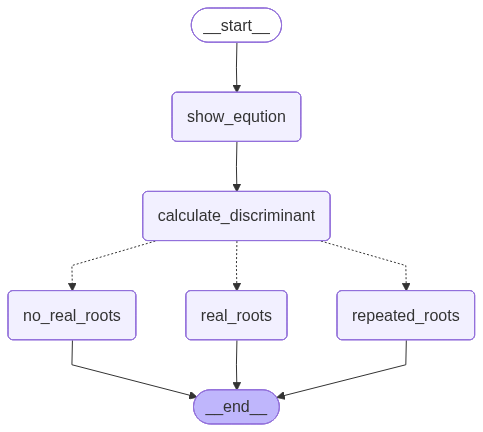

In [5]:
workflow

In [6]:
inital_state = {
    'a' :4,
    'b':-5,
    'c' :-4
}

final_state = workflow.invoke(inital_state)

In [7]:
print(final_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x2 -5x -4', 'discriminant': 89, 'result': ' The roots are 1.8042476415070754 and -0.5542476415070754'}
